In [7]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import colorsys
%matplotlib notebook

<IPython.core.display.Javascript object>


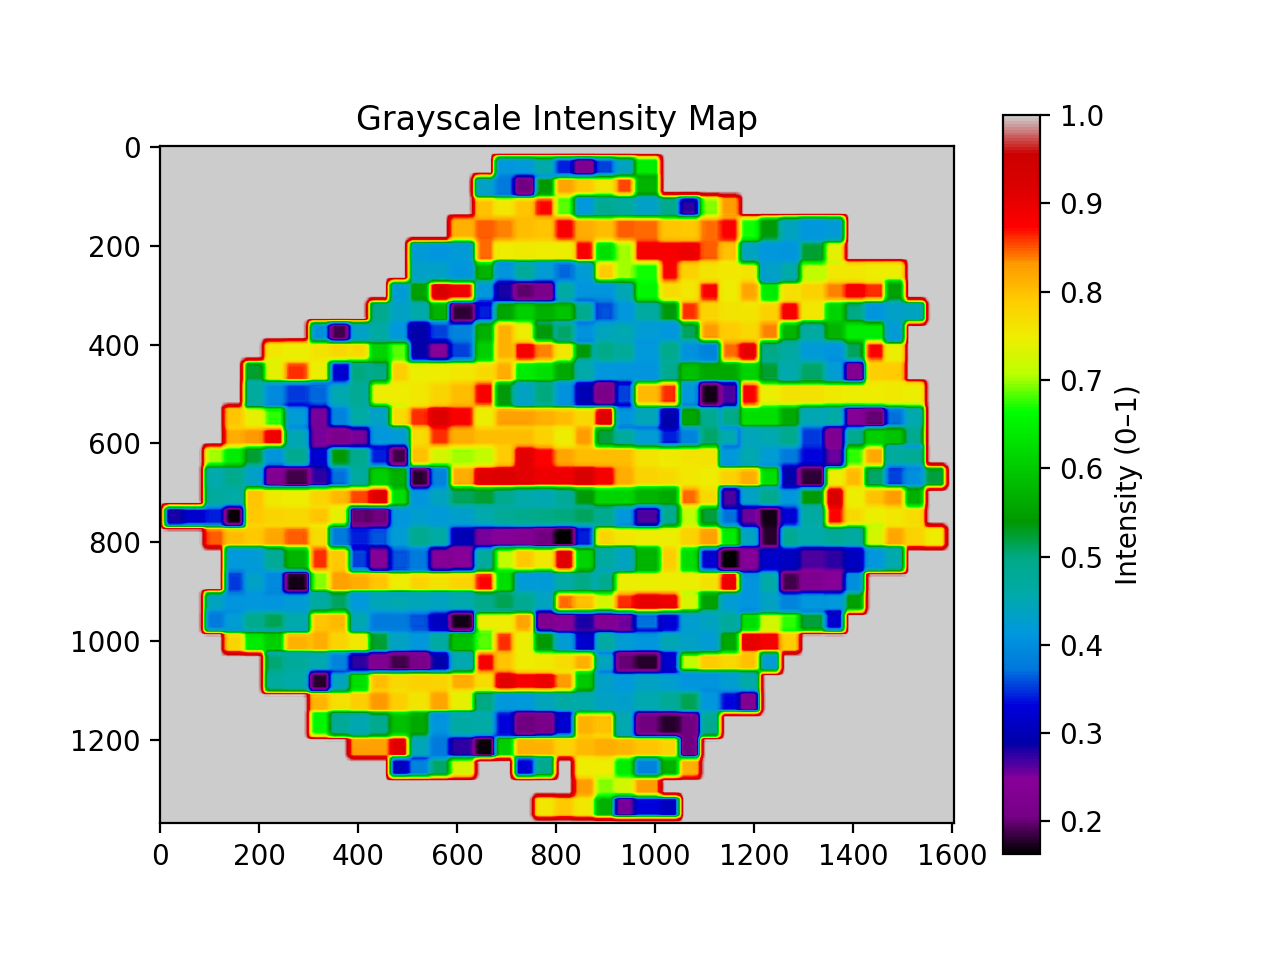

In [22]:
path = '/Users/eriklamb/Documents/Data/PETRA/PETRA_P10_November2023/Beamtime_11017686/nps_cdi.png'

fig,ax = plt.subplots()


# Load image
img = Image.open(path).convert("RGB")
img_array = np.array(img) / 255.0  # normalize to [0,1]

# Convert RGB to grayscale intensity (luminance)
intensity = 0.299 * img_array[...,0] + 0.587 * img_array[...,1] + 0.114 * img_array[...,2]
intensity[intensity==1] = 0

# Show intensity map
plt.imshow(intensity, cmap="nipy_spectral")
plt.colorbar(label="Intensity (0–1)")
plt.title("Grayscale Intensity Map")
plt.show()



In [24]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import colorsys
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from matplotlib import cm
from matplotlib.colors import Normalize

# Load screenshot
img = Image.open(path).convert("RGB")
img_array = np.array(img) / 255.0

# Flatten to Nx3 array
pixels = img_array.reshape(-1, 3)

# Define the colormap and normalization
cmap = cm.get_cmap("hsv")
norm = Normalize(vmin=-np.pi, vmax=np.pi)

# Build lookup table: sample RGB for many phase values
phase_vals = np.linspace(-np.pi, np.pi, 2048)
rgb_vals = cmap(norm(phase_vals))[:, :3]  # drop alpha

# Find nearest RGB in colormap for each pixel
# (broadcasted difference -> squared error -> argmin)
diffs = np.sum((pixels[:, None, :] - rgb_vals[None, :, :])**2, axis=-1)
nearest_idx = np.argmin(diffs, axis=1)
phases = phase_vals[nearest_idx]

# Mask out nearly white background (optional)
mask = ~(np.all(pixels > 0.95, axis=1))
phases = phases[mask]

# Plot histogram
plt.figure(figsize=(7,4))
plt.hist(phases, bins=180, range=(-np.pi, np.pi), color="purple", alpha=0.7)
plt.axvline(0, color="k", ls="--", label="0")
plt.axvline(2*np.pi/3, color="r", ls="--", label="2π/3")
plt.axvline(-2*np.pi/3, color="b", ls="--", label="-2π/3")
plt.xlabel("Phase (radians)")
plt.ylabel("Count")
plt.title("Phase Histogram (decoded from hsv colormap)")
plt.legend()
plt.show()



/var/folders/wg/d6rgw7nd3p9gs4wz8ngmmpj00000gn/T/ipykernel_752/2534478219.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("hsv")


KeyboardInterrupt: 

<IPython.core.display.Javascript object>


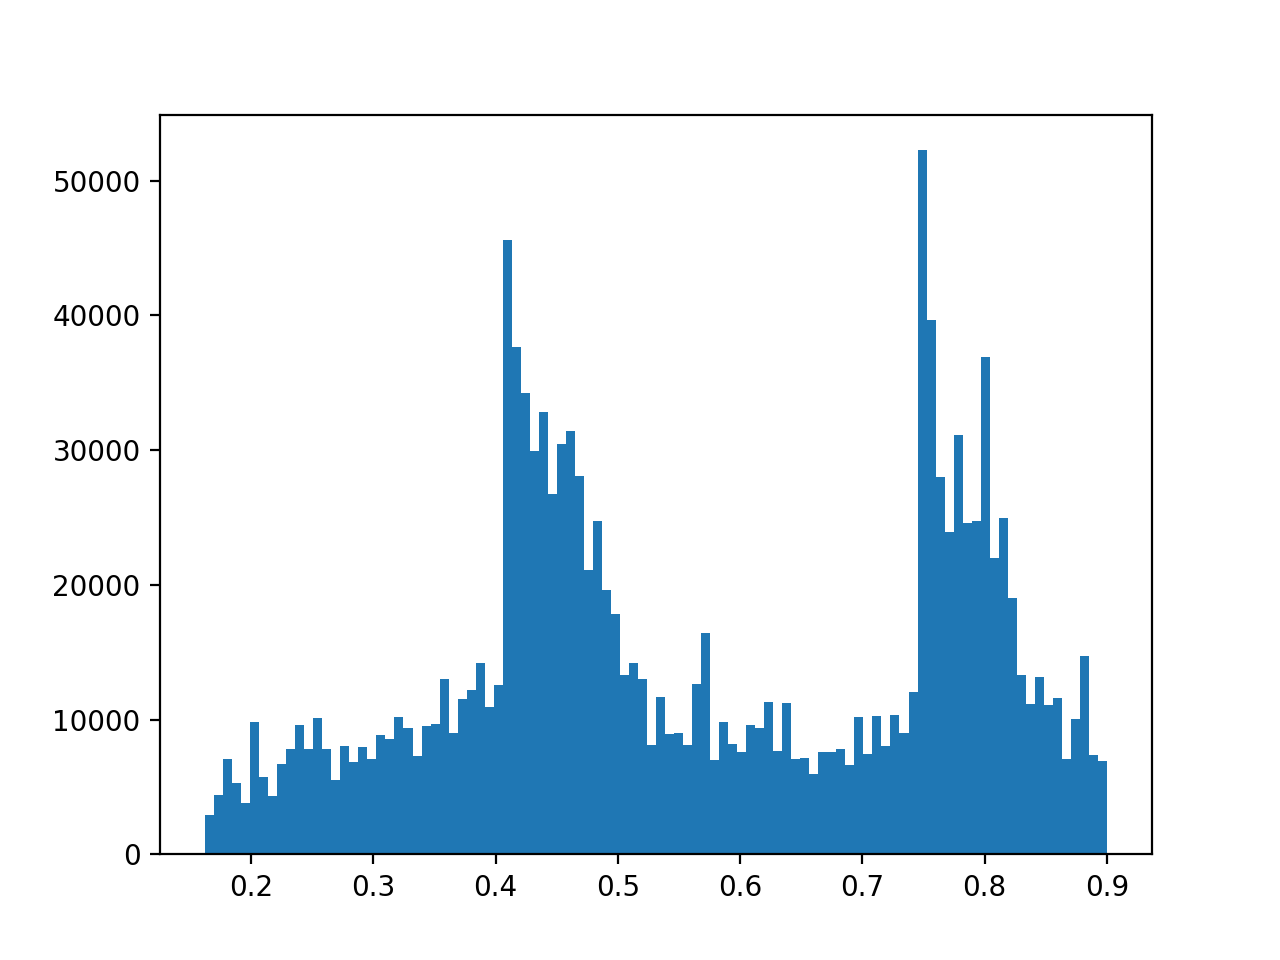

(array([ 2956.,  4374.,  7080.,  5325.,  3829.,  9844.,  5730.,  4309.,
         6694.,  7822.,  9619.,  7799., 10104.,  7830.,  5492.,  8040.,
         6863.,  8007.,  7115.,  8896.,  8571., 10196.,  9366.,  7299.,
         9549.,  9689., 13038.,  8979., 11530., 12229., 14215., 10923.,
        12536., 45558., 37688., 34205., 29955., 32838., 26756., 30440.,
        31411., 28081., 21139., 24757., 19585., 17847., 13312., 14223.,
        13024.,  8147., 11672.,  8942.,  8997.,  8111., 12614., 16426.,
         6975.,  9846.,  8167.,  7579.,  9589.,  9387., 11288.,  7678.,
        11272.,  7082.,  7171.,  5997.,  7583.,  7611.,  7827.,  6606.,
        10186.,  7460., 10304.,  8042., 10365.,  9039., 12032., 52244.,
        39683., 28008., 23900., 31152., 24585., 24726., 36882., 21985.,
        24938., 19056., 13333., 11149., 13154., 11073., 11640.,  7052.,
        10041., 14701.,  7370.,  6937.]),
 array([0.16247451, 0.16984976, 0.17722502, 0.18460027, 0.19197553,
        0.19935078, 0.2067

In [20]:
fig, ax = plt.subplots()

ax.hist(intensity[intensity<0.9],bins=100)